In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("All imports successful.")

All imports successful.


In [3]:
df = pd.read_csv('data/processed/telco_churn_processed.csv')

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Features shape: (7043, 31)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Train size: (5634, 31)
Test size:  (1409, 31)
Train churn rate: 26.5%
Test churn rate:  26.5%


In [5]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [6]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Model training complete.")

Model training complete.


In [7]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("MODEL PERFORMANCE — XGBoost")
print("=" * 45)
print(f"Accuracy:   {acc*100:.2f}%")
print(f"Precision:  {prec*100:.2f}%")
print(f"Recall:     {rec*100:.2f}%")
print(f"F1-Score:   {f1*100:.2f}%")
print(f"ROC-AUC:    {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

MODEL PERFORMANCE — XGBoost
Accuracy:   77.22%
Precision:  56.85%
Recall:     58.82%
F1-Score:   57.82%
ROC-AUC:    0.8318

Classification Report:
              precision    recall  f1-score   support

    Retained       0.85      0.84      0.84      1035
     Churned       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



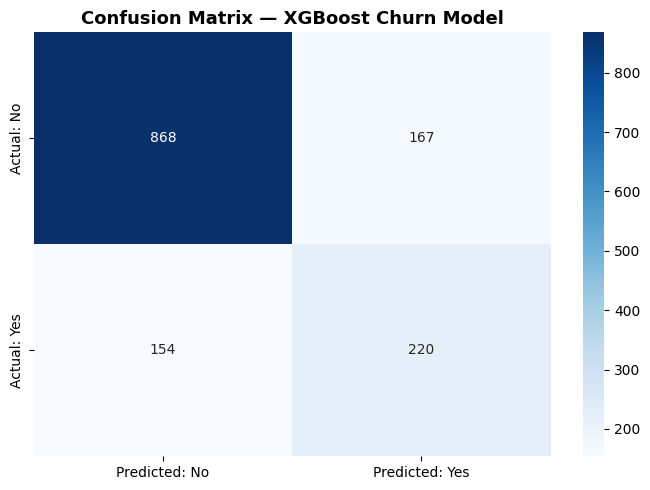

True Negatives (correctly kept):    868
False Positives (false alarms):     167
False Negatives (missed churners):  154
True Positives (caught churners):   220


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix — XGBoost Churn Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly kept):    {tn}")
print(f"False Positives (false alarms):     {fp}")
print(f"False Negatives (missed churners):  {fn}")
print(f"True Positives (caught churners):   {tp}")

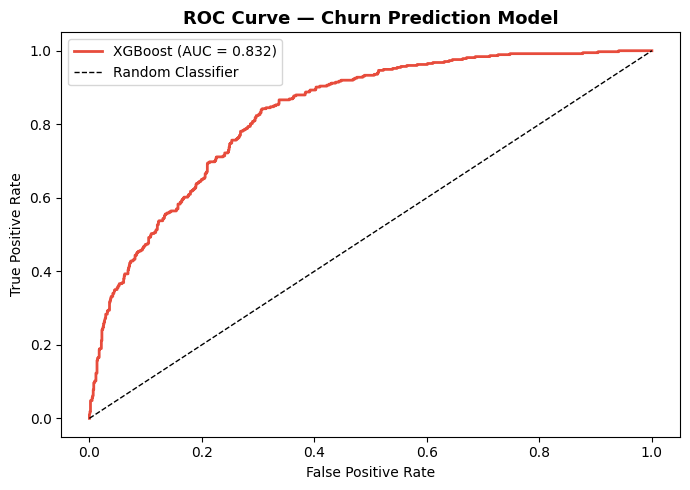

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction Model', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

print("5-Fold Cross Validation — ROC-AUC:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\n  Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross Validation — ROC-AUC:
  Fold 1: 0.8519
  Fold 2: 0.8355
  Fold 3: 0.8468
  Fold 4: 0.8234
  Fold 5: 0.8311

  Mean AUC: 0.8377 (+/- 0.0104)


In [11]:
with open('models/xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature names for later use
feature_names = list(X.columns)
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Model saved to models/xgb_churn_model.pkl")
print(f"Features saved: {len(feature_names)} features")

Model saved to models/xgb_churn_model.pkl
Features saved: 31 features


In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_sm, y_train_sm)
print(f"Best AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best AUC: 0.9340
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [13]:
best_model = search.best_estimator_

y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Find optimal threshold using F1 score
from sklearn.metrics import f1_score
thresholds = np.arange(0.2, 0.6, 0.01)
f1_scores = [f1_score(y_test, (y_prob_tuned >= t).astype(int)) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_threshold:.2f}")

y_pred_tuned = (y_prob_tuned >= optimal_threshold).astype(int)

acc   = accuracy_score(y_test, y_pred_tuned)
prec  = precision_score(y_test, y_pred_tuned)
rec   = recall_score(y_test, y_pred_tuned)
f1    = f1_score(y_test, y_pred_tuned)
auc   = roc_auc_score(y_test, y_prob_tuned)

print("=" * 45)
print("TUNED MODEL PERFORMANCE")
print("=" * 45)
print(f"Accuracy:   {acc*100:.2f}%")
print(f"Precision:  {prec*100:.2f}%")
print(f"Recall:     {rec*100:.2f}%")
print(f"F1-Score:   {f1*100:.2f}%")
print(f"ROC-AUC:    {auc:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))

# Save tuned model and threshold
with open('models/xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('models/optimal_threshold.pkl', 'wb') as f:
    pickle.dump(optimal_threshold, f)

print("Tuned model saved.")

Optimal threshold: 0.27
TUNED MODEL PERFORMANCE
Accuracy:   74.17%
Precision:  50.84%
Recall:     80.48%
F1-Score:   62.32%
ROC-AUC:    0.8325

              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Tuned model saved.
